# **Convolutional Neural Network w/o Preprocessing**

In [1]:
!lscpu

Architecture:             x86_64
  CPU op-mode(s):         32-bit, 64-bit
  Address sizes:          46 bits physical, 48 bits virtual
  Byte Order:             Little Endian
CPU(s):                   4
  On-line CPU(s) list:    0-3
Vendor ID:                GenuineIntel
  Model name:             Intel(R) Xeon(R) CPU @ 2.00GHz
    CPU family:           6
    Model:                85
    Thread(s) per core:   2
    Core(s) per socket:   2
    Socket(s):            1
    Stepping:             3
    BogoMIPS:             4000.32
    Flags:                fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge m
                          ca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht sysc
                          all nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xt
                          opology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq
                           ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt
                           aes xsave avx f16c rdrand hypervisor 

In [2]:
!nvidia-smi

Wed Feb  5 03:24:48 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P0             28W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## **Importing Libraries**

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.layers import LeakyReLU, GlobalAveragePooling2D

## **Loading the Dataset**

In [4]:
dataset_path = '/kaggle/input/ichigo/Resized Image'

subfolders = sorted(os.listdir(dataset_path))
print("Subfolders:", subfolders)

Subfolders: ['FreshApple', 'FreshBanana', 'FreshGrape', 'FreshGuava', 'FreshJujube', 'FreshOrange', 'FreshPomegranate', 'FreshStrawberry', 'RottenApple', 'RottenBanana', 'RottenGrape', 'RottenGuava', 'RottenJujube', 'RottenOrange', 'RottenPomegranate', 'RottenStrawberry']


In [5]:
images = []
labels = []

for label, folder in enumerate(subfolders):
    folder_path = os.path.join(dataset_path, folder)

    for img_file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_file)
        img = cv2.imread(img_path)

        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            labels.append(label)
        else:
            print(f"Failed to load image: {img_path}")

images = np.array(images)
labels = np.array(labels)

In [6]:
print("Original shape of the images: ", images.shape)
print("Original shape of the labels: ", labels.shape)

Original shape of the images:  (3200, 256, 256, 3)
Original shape of the labels:  (3200,)


In [7]:
images = images.astype('float32') / 255.0

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

In [8]:
print("Shape of X train:", X_train.shape)
print("Shape of X test :", X_test.shape, '\n')

print("Shape of y train:", y_train.shape)
print("Shape of y test :", y_test.shape)

Shape of X train: (2560, 256, 256, 3)
Shape of X test : (640, 256, 256, 3) 

Shape of y train: (2560,)
Shape of y test : (640,)


## **Model Training**

In [9]:
input_shape = X_train.shape[1:]
num_classes = len(subfolders)

model = models.Sequential([
    layers.Input(shape=input_shape),
    
    layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    LeakyReLU(alpha=0.1),
    layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    LeakyReLU(alpha=0.1),
    layers.MaxPooling2D((2,2)),
    layers.SpatialDropout2D(0.2),

    layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    LeakyReLU(alpha=0.1),
    layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    LeakyReLU(alpha=0.1),
    layers.MaxPooling2D((2,2)),
    layers.SpatialDropout2D(0.3),

    layers.Conv2D(256, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    LeakyReLU(alpha=0.1),
    layers.Conv2D(256, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    LeakyReLU(alpha=0.1),
    layers.MaxPooling2D((2,2)),
    layers.SpatialDropout2D(0.4),

    layers.GlobalAveragePooling2D(),
    
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 256, 256, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256, 256, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 256, 256, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 256, 256, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256, 256, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 256, 256, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 128, 128, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout2d (SpatialDropout2D) │ (None, 128, 128, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 128, 128, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128, 128, 128)       │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 128, 128, 128)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 128, 128, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128, 128, 128)       │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 128, 128, 128)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 64, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout2d_1                  │ (None, 64, 64, 128)         │               0 │
│ (SpatialDropout2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 64, 64, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64, 64, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,219,920 (4.65 MB)

 Trainable params: 1,217,616 (4.64 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [11]:
history = model.fit(X_train, y_train,
                    epochs=10, batch_size=32,
                    validation_split=0.2)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 235ms/step - accuracy: 0.1998 - loss: 4.1567 - val_accuracy: 0.0684 - val_loss: 4.0132
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 198ms/step - accuracy: 0.3823 - loss: 2.9585 - val_accuracy: 0.0879 - val_loss: 4.4000
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - accuracy: 0.4291 - loss: 2.7554 - val_accuracy: 0.0898 - val_loss: 5.0892
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - accuracy: 0.5089 - loss: 2.4978 - val_accuracy: 0.2363 - val_loss: 4.4464
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - accuracy: 0.5249 - loss: 2.3839 - val_accuracy: 0.1895 - val_loss: 3.8737
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/step - accuracy: 0.5769 - loss: 2.1528 - val_accuracy: 0.3867 - val_loss: 2.8094
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - accuracy: 0.6046 - loss: 2.0723 - val_accuracy: 0.5371 - val_loss: 2.2164
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/step - accuracy: 0.6094 - loss: 2.0537 - val_accu

## **Model Testing**

In [12]:
y_pred_probs = model.predict(X_test)
y_pred_cnn = np.argmax(y_pred_probs, axis=1)

accuracy_cnn = accuracy_score(y_test, y_pred_cnn)
print(f"CNN Accuracy: {accuracy_cnn:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step
CNN Accuracy: 0.7250


In [13]:
average_precision = precision_score(y_test, y_pred_cnn, average='macro')
average_recall = recall_score(y_test, y_pred_cnn, average='macro')
average_f1 = f1_score(y_test, y_pred_cnn, average='macro')

print(f"Average Precision: {average_precision:.4f}")
print(f"Average Recall: {average_recall:.4f}")
print(f"Average F1-Score: {average_f1:.4f}")

Average Precision: 0.7450
Average Recall: 0.7275
Average F1-Score: 0.7084


In [14]:
print("CNN Classification Report:\n")
print(classification_report(y_test, y_pred_cnn, target_names=subfolders))

CNN Classification Report:

                   precision    recall  f1-score   support

       FreshApple       0.79      0.89      0.83        54
      FreshBanana       0.87      0.91      0.89        43
       FreshGrape       1.00      0.45      0.62        56
       FreshGuava       0.90      1.00      0.95        35
      FreshJujube       0.85      0.88      0.87        33
      FreshOrange       0.88      0.58      0.70        36
 FreshPomegranate       0.94      0.87      0.90        38
  FreshStrawberry       0.87      1.00      0.93        48
      RottenApple       0.43      0.39      0.41        41
     RottenBanana       0.70      0.47      0.57        40
      RottenGrape       0.59      0.98      0.74        44
      RottenGuava       0.47      0.74      0.57        39
     RottenJujube       0.56      0.88      0.68        32
     RottenOrange       0.84      0.87      0.86        31
RottenPomegranate       0.67      0.15      0.25        39
 RottenStrawberry       0.5

## **Visualisation**

### **Training and Validation Accuracy**

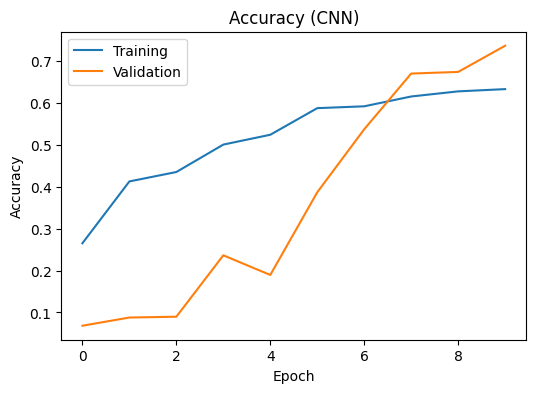

In [15]:
plt.figure(figsize=(6, 4))

plt.title('Accuracy (CNN)')
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

### **Training and Validation Loss**

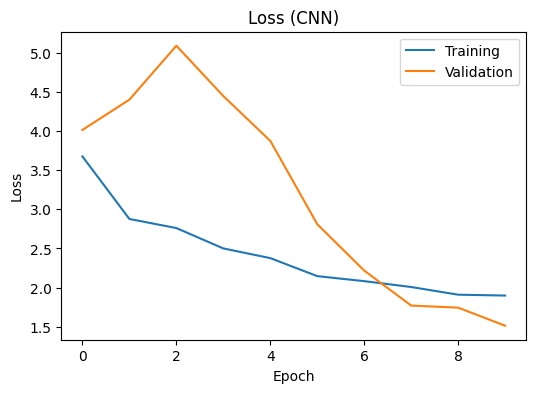

In [16]:
plt.figure(figsize=(6, 4))

plt.title('Loss (CNN)')
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.show()

### **Confusion Matrix**

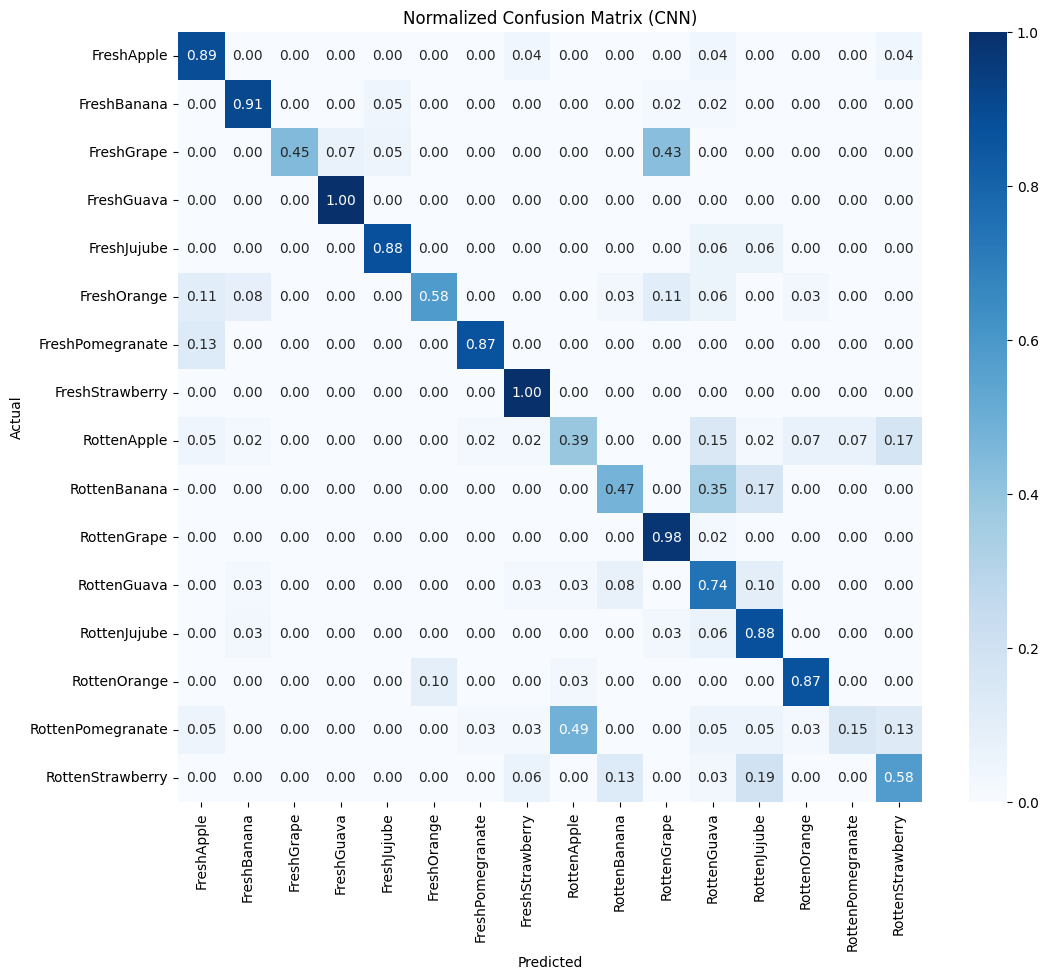

In [17]:
conf_matrix_cnn = confusion_matrix(y_test, y_pred_cnn)

conf_matrix_cnn_normalised = conf_matrix_cnn.astype('float') / conf_matrix_cnn.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_cnn_normalised, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=subfolders, yticklabels=subfolders)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Normalized Confusion Matrix (CNN)')
plt.show()

### **Class-wise Precision, Recall, and F1-Score**

In [18]:
precision = precision_score(y_test, y_pred_cnn, average=None)
recall = recall_score(y_test, y_pred_cnn, average=None)
f1 = f1_score(y_test, y_pred_cnn, average=None)

class_metrics = pd.DataFrame({
    'Class': subfolders,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
})

print("Class-wise Precision, Recall, and F1-Score:")
print(class_metrics)

Class-wise Precision, Recall, and F1-Score:
                Class  Precision    Recall  F1-Score
0          FreshApple   0.786885  0.888889  0.834783
1         FreshBanana   0.866667  0.906977  0.886364
2          FreshGrape   1.000000  0.446429  0.617284
3          FreshGuava   0.897436  1.000000  0.945946
4         FreshJujube   0.852941  0.878788  0.865672
5         FreshOrange   0.875000  0.583333  0.700000
6    FreshPomegranate   0.942857  0.868421  0.904110
7     FreshStrawberry   0.872727  1.000000  0.932039
8         RottenApple   0.432432  0.390244  0.410256
9        RottenBanana   0.703704  0.475000  0.567164
10        RottenGrape   0.589041  0.977273  0.735043
11        RottenGuava   0.467742  0.743590  0.574257
12       RottenJujube   0.560000  0.875000  0.682927
13       RottenOrange   0.843750  0.870968  0.857143
14  RottenPomegranate   0.666667  0.153846  0.250000
15   RottenStrawberry   0.562500  0.580645  0.571429


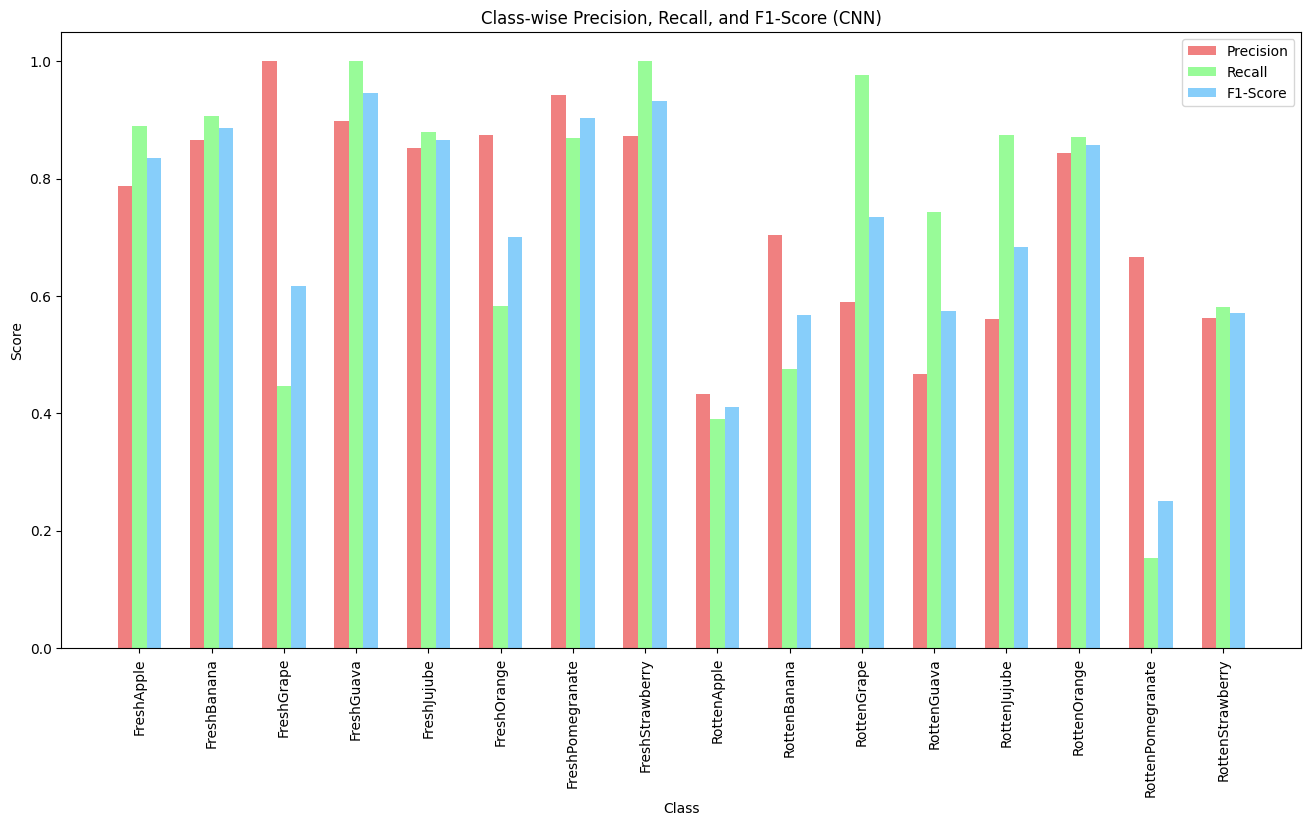

In [19]:
plt.figure(figsize=(16, 8))
x = np.arange(len(subfolders))
width = 0.2

plt.bar(x - width, precision, width, label='Precision', color='lightcoral')
plt.bar(x, recall, width, label='Recall', color='palegreen')
plt.bar(x + width, f1, width, label='F1-Score', color='lightskyblue')

plt.title('Class-wise Precision, Recall, and F1-Score (CNN)')
plt.xlabel('Class')
plt.ylabel('Score')
plt.xticks(x, subfolders, rotation=90)
plt.legend()
plt.show()

## **Exporting Model**

In [20]:
model.save('/kaggle/working/CNN_NoPreprocessing.h5')